# Regularización

En este notebook revisaremos cómo Ridge, Lasso y Elastic Net controlan la complejidad del modelo.


Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)



## Instrucciones

Este notebook combina celdas demostrativas con preguntas de análisis.

No basta con ejecutar el código: deben interpretar los resultados, comparar métricas y justificar sus respuestas usando gráficos, coeficientes y residuos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(16)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12

In [2]:
def regression_metrics(y_true, y_pred, label="modelo"):
    # Calcula métricas básicas de regresión.
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame(
        {
            "modelo": [label],
            "MAE": [mae],
            "MSE": [mse],
            "RMSE": [rmse],
            "R2": [r2],
        }
    )


def plot_real_vs_pred(y_true, y_pred, title="Valores reales vs predichos"):
    # Gráfico y_true vs y_pred. La línea punteada representa predicción perfecta.
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.75)
    lims = [
        min(np.min(y_true), np.min(y_pred)),
        max(np.max(y_true), np.max(y_pred)),
    ]
    plt.plot(lims, lims, linestyle="--", label=r"$\hat{y}=y$")
    plt.xlabel("Valor real")
    plt.ylabel("Valor predicho")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


def plot_residuals(y_true, y_pred, x_axis=None, title="Residuos"):
    # Gráfico de residuos.
    residuals = y_true - y_pred
    if x_axis is None:
        x_axis = y_pred
        xlabel = "Valor predicho"
    else:
        xlabel = "x"

    plt.figure(figsize=(8, 4.8))
    plt.scatter(x_axis, residuals, alpha=0.75)
    plt.axhline(0, linestyle="--")
    plt.xlabel(xlabel)
    plt.ylabel(r"Residuo: $y-\hat{y}$")
    plt.title(title)
    plt.grid(alpha=0.25)
    plt.show()

# Regularización

Hasta ahora hemos visto que un modelo puede fallar por ser demasiado simple o por ajustarse demasiado a los datos de entrenamiento.

En esta parte vamos a construir un ejemplo donde se vea claramente por qué puede ayudar la regularización.

La idea será:
1. partir con un modelo demasiado simple
2. aumentar la complejidad usando features polinomiales
3. observar el riesgo de sobreajuste
4. usar Ridge, Lasso y Elastic Net para controlar esa complejidad

**Recordemos**


La regresión lineal sin regularización busca minimizar solo el error:

$$
L(\beta)=MSE
$$

Pero si el modelo tiene muchas variables, variables correlacionadas o ruido, puede ajustar patrones accidentales del conjunto de entrenamiento.

La regularización agrega una penalización sobre los coeficientes.

#### Ridge

$$
L(\beta)=MSE+\alpha\sum_j \beta_j^2
$$

Penaliza coeficientes grandes, pero normalmente no los lleva exactamente a cero.

#### Lasso

$$
L(\beta)=MSE+\alpha\sum_j |\beta_j|
$$

Puede llevar algunos coeficientes exactamente a cero, actuando como selección de variables.

#### Elastic Net

$$
L(\beta)=MSE+\alpha\left[
r\sum_j|\beta_j|+\frac{1-r}{2}\sum_j\beta_j^2
\right]
$$

Combina selección de variables con estabilización de coeficientes.

#### Crearemos un problema con muchas features

Vamos a crear datos artificiales donde conocemos la relación real:

$$
y = 2 + 1.5x - 0.8x^2 + 0.3x^3 + \epsilon
$$

La relación no es una recta, sino una curva suave. Esto nos permite estudiar qué pasa cuando usamos modelos con distinta complejidad.

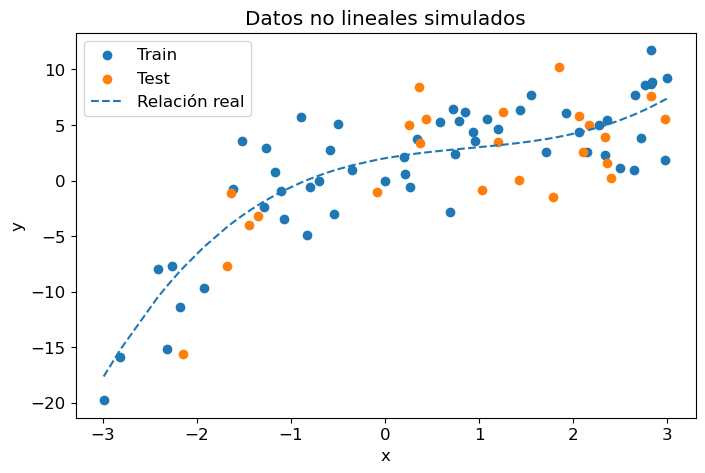

In [5]:
np.random.seed(24)

N_poly = 80
x_poly = np.sort(np.random.uniform(-3, 3, N_poly))

# Relación real no lineal, pero suave.
y_poly_true = 2 + 1.5*x_poly - 0.8*x_poly**2 + 0.3*x_poly**3

# Ruido
y_poly = y_poly_true + np.random.normal(0, 3.0, size=N_poly)

X_poly = x_poly.reshape(-1, 1)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly, y_poly, test_size=0.3, random_state=3
)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_p[:, 0], y_train_p, label="Train")
plt.scatter(X_test_p[:, 0], y_test_p, label="Test")
plt.plot(x_poly, y_poly_true, linestyle="--", label="Relación real")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos no lineales simulados")
plt.legend()
plt.grid(False)
plt.show()

#### Pregunta
- Qué podría pasar si ajustamos una regresión lineal simple?
- Qué podría pasar si usamos un polinomio de grado muy alto?

1. el modelo va a ser muy simple 
2. el modelo va a ser muy compleajo y va a perder capacidad de genralizacion

#### Comparación: modelo lineal, polinomial sin regularización y modelos regularizados

Una regresión lineal simple ajusta:

$$
y = \beta_0 + \beta_1x
$$

Pero podemos crear nuevas variables a partir de $x$:
$$x,\ x^2,\ x^3,\dots$$

Entonces el modelo puede ajustar:

$$y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \dots$$

Esto sigue siendo un modelo lineal en los coeficientes $\beta$, pero ahora es más flexible respecto a $x$.

Compararemos tres niveles de complejidad:

- Lineal simple
- Polinomial grado 3
- Polinomial grado 15

**Preguntas**
- ¿Cuál modelo crees que tendrá menor error de entrenamiento?
- ¿Cuál modelo crees que tendrá mayor riesgo de overfitting?
- ¿Cuál modelo esperas que generalice mejor?

1. el polinomio de grado 15
2. el polinimio de grado 15
3. el polinomio de grado 3

In [8]:
def evaluate_model(model, X_train, X_test, y_train, y_test, label):
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    return {
        "modelo": label,
        "RMSE train": np.sqrt(mean_squared_error(y_train, pred_train)),
        "RMSE test": np.sqrt(mean_squared_error(y_test, pred_test)),
        "MAE test": mean_absolute_error(y_test, pred_test),
        "R2 test": r2_score(y_test, pred_test)
    }

# Grados que usaremos para comparar complejidad
degree_good = 3
degree_high = 15

models_complexity = {
    "Lineal simple": make_pipeline(
        StandardScaler(),
        LinearRegression()
    ),
    "Polinomial grado 3": make_pipeline(
        PolynomialFeatures(degree=degree_good, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ),
    "Polinomial grado 15": make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ),
}

results_complexity = []
for name, model in models_complexity.items():
    results_complexity.append(
        evaluate_model(model, X_train_p, X_test_p, y_train_p, y_test_p, name)
    )

results_complexity = pd.DataFrame(results_complexity)
results_complexity

,modelo,RMSE train,RMSE test,MAE test,R2 test
0,Lineal simple,4.045836,4.146417,3.346527,0.434858
1,Polinomial grado 3,2.990554,3.432214,2.839215,0.612778
2,Polinomial grado 15,2.511185,3.775464,3.150510,0.531454


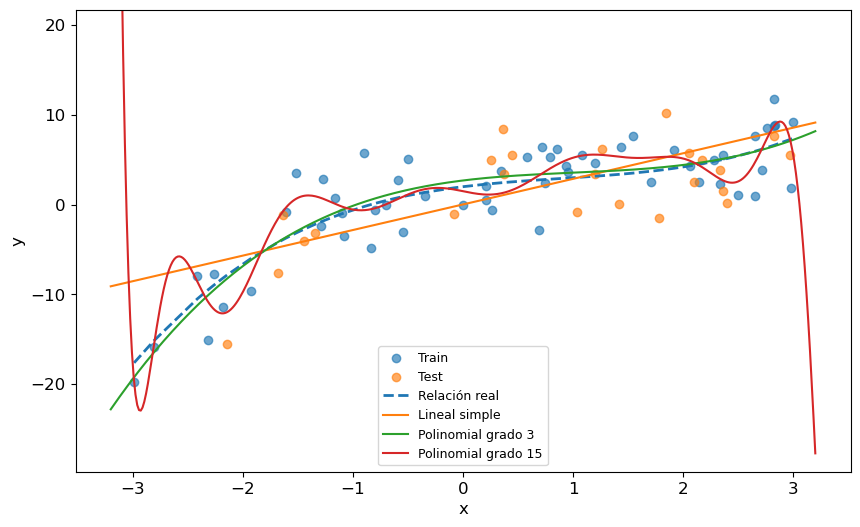

In [10]:
x_plot = np.linspace(-3.2, 3.2, 400).reshape(-1, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_p[:, 0], y_train_p, alpha=0.65, label="Train")
plt.scatter(X_test_p[:, 0], y_test_p, alpha=0.65, label="Test")
plt.plot(x_poly, y_poly_true, linestyle="--", linewidth=2, label="Relación real")

for name, model in models_complexity.items():
    plt.plot(x_plot[:, 0], model.predict(x_plot), label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=9)
plt.ylim(y_poly.min() - 10, y_poly.max() + 10)
plt.grid(False)
plt.show()

#### Regularización sobre un modelo flexible
Ahora tomaremos el modelo de grado 15, que tiene mucha flexibilidad, y veremos si la regularización ayuda a controlarlo.

Usaremos:

- **RidgeCV:** busca automáticamente el mejor $\alpha$ para Ridge.
- **LassoCV:** busca automáticamente el mejor $\alpha$ para Lasso.
- **ElasticNetCV:** busca $\alpha$ y también la mezcla entre L1 y L2.

Usaremos `StandardScaler` porque Ridge, Lasso y Elastic Net penalizan directamente el tamaño de los coeficientes. Si las variables están en escalas distintas, la penalización puede depender más de las unidades de medida que de la importancia real de cada variable.

En regresión lineal sin regularización, escalar no es estrictamente necesario para obtener buenas predicciones, pero ayuda a comparar coeficientes y mejora la estabilidad numérica, especialmente cuando usamos características polinomiales.

**Preguntas**
- ¿Esperas que Ridge elimine variables?
- ¿Esperas que Lasso elimine variables?
- ¿Qué esperas que pase con las curvas regularizadas comparadas con el polinomio grado 15 sin regularización?


1. no
2. si
3. que no este sobreajustando

In [13]:
alphas = np.logspace(-2, 4, 80)

models_regularized = {
    "Polinomial grado 15": make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        LinearRegression()
    ),
    "RidgeCV grado 15": make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        RidgeCV(alphas=alphas, cv=5)
    ),
    "LassoCV grado 15": make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        LassoCV(alphas=alphas, cv=5, max_iter=1000000, tol=1e-4, random_state=1)
    ),
    "ElasticNetCV grado 15": make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        ElasticNetCV(
            alphas=alphas,
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
            cv=5,
            max_iter=1000000,
            tol=1e-4,
            random_state=1
        )
    )
}

results_regularized = []
for name, model in models_regularized.items():
    results_regularized.append(
        evaluate_model(model, X_train_p, X_test_p, y_train_p, y_test_p, name)
    )

results_regularized = pd.DataFrame(results_regularized)
results_regularized

,modelo,RMSE train,RMSE test,MAE test,R2 test
0,Polinomial grado 15,2.511185,3.775464,3.150510,0.531454
1,RidgeCV grado 15,3.072016,3.741211,3.059771,0.539918
2,LassoCV grado 15,2.984765,3.521203,2.901566,0.592438
3,ElasticNetCV grado 15,3.016037,3.636813,2.986319,0.565236


In [15]:
# Hiperparámetros elegidos por validación cruzada
selected_params = []

for name in ["RidgeCV grado 15", "LassoCV grado 15", "ElasticNetCV grado 15"]:
    estimator = models_regularized[name][-1]
    row = {"modelo": name}
    if hasattr(estimator, "alpha_"):
        row["alpha elegido"] = estimator.alpha_
    if hasattr(estimator, "l1_ratio_"):
        row["l1_ratio elegido"] = estimator.l1_ratio_
    selected_params.append(row)

pd.DataFrame(selected_params)

,modelo,alpha elegido,l1_ratio elegido
0,RidgeCV grado 15,10.913767,NaN
1,LassoCV grado 15,0.115689,NaN
2,ElasticNetCV grado 15,0.164131,0.5


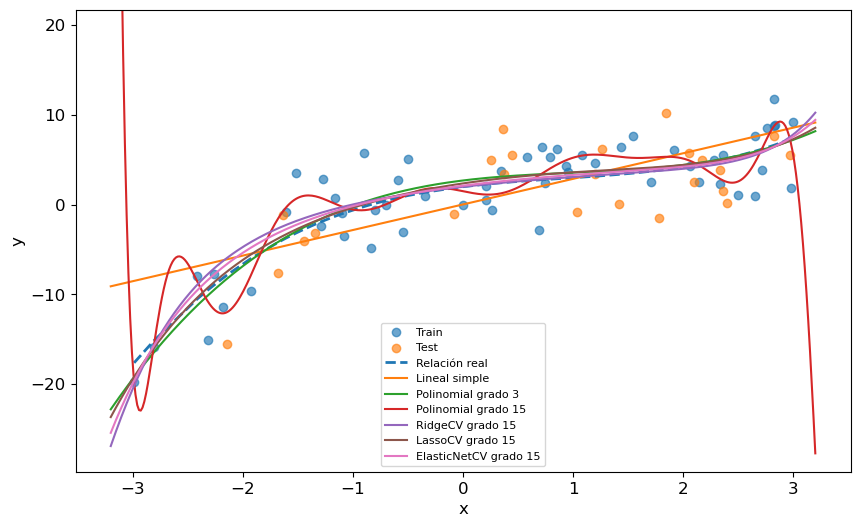

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_p[:, 0], y_train_p, alpha=0.65, label="Train")
plt.scatter(X_test_p[:, 0], y_test_p, alpha=0.65, label="Test")
plt.plot(x_poly, y_poly_true, linestyle="--", linewidth=2, label="Relación real")

# Incluimos también los modelos de referencia para comparar
plot_models = {
    "Lineal simple": models_complexity["Lineal simple"],
    "Polinomial grado 3": models_complexity["Polinomial grado 3"],
    **models_regularized
}

for name, model in plot_models.items():
    plt.plot(x_plot[:, 0], model.predict(x_plot), label=name)

plt.xlabel("x")
plt.ylabel("y")
plt.legend(fontsize=8)
plt.ylim(y_poly.min() - 10, y_poly.max() + 10)
plt.grid(False)
plt.show()

**Preguntas**
- ¿Qué modelo tiene mejor desempeño en train?
- ¿Qué modelo tiene mejor desempeño en test?
- ¿Qué diferencias visuales ves entre el polinomio grado 15 sin regularización y los modelos regularizados?
- ¿La regularización parece aumentar o disminuir la flexibilidad del modelo?
- ¿Por qué no deberíamos elegir un modelo mirando solo el error de entrenamiento?

1. el polinomio grado 15
2. Lasso
3. los modelos regularizados se parecen al polinomio de grado 3
4. parece disminuirla
5. porque no nos dice acerca de su capacidad de generalizar

#### Coeficientes
Ahora miraremos los coeficientes asociados a las features polinomiales

In [19]:
def get_polynomial_feature_names(degree):
    return ["x" if i == 1 else f"x^{i}" for i in range(1, degree + 1)]

coef_table = pd.DataFrame({"feature": get_polynomial_feature_names(degree_high)})

for name in ["Polinomial grado 15", "RidgeCV grado 15", "LassoCV grado 15", "ElasticNetCV grado 15"]:
    estimator = models_regularized[name][-1]
    coef_table[name] = np.ravel(estimator.coef_)

coef_table

,feature,Polinomial grado 15,RidgeCV grado 15,LassoCV grado 15,ElasticNetCV grado 15
0,x,-4.309332,2.394130,3.142426,2.735857
1,x^2,-0.418161,-1.191703,-2.091629,-1.460572
2,x^3,191.781505,1.480033,1.537999,1.602253
3,x^4,23.791145,-0.909226,-0.642127,-1.050360
4,x^5,-1613.200116,0.955784,1.445029,0.950073
5,x^6,121.258057,-0.461962,-0.000000,-0.127589
6,x^7,6156.019885,0.616951,0.000000,0.519338
7,x^8,-1285.641494,-0.154773,-0.000000,-0.000000
8,x^9,-11856.979150,0.375169,0.000000,0.195496
9,x^10,3072.521695,0.003817,0.000000,-0.000000


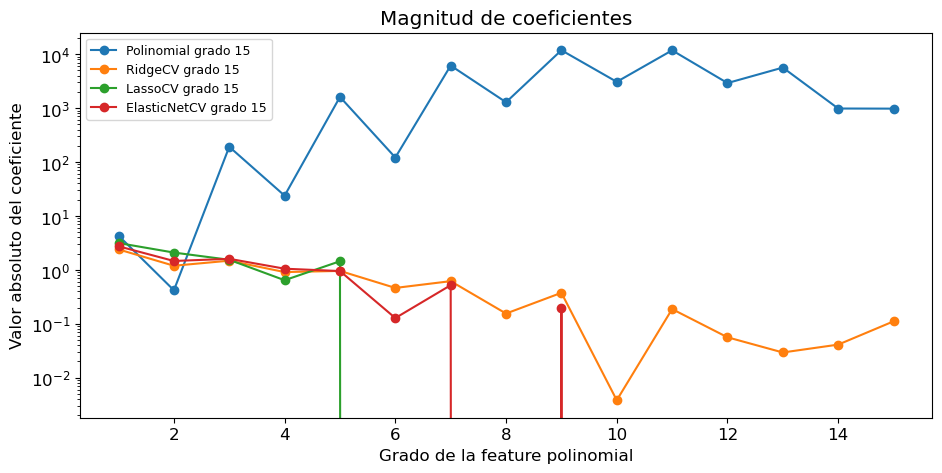

In [21]:
plt.figure(figsize=(11, 5))
positions = np.arange(1, degree_high + 1)

for name in ["Polinomial grado 15", "RidgeCV grado 15", "LassoCV grado 15", "ElasticNetCV grado 15"]:
    plt.plot(positions, np.abs(coef_table[name]), marker="o", label=name)

plt.yscale("log")
plt.xlabel("Grado de la feature polinomial")
plt.ylabel("Valor absoluto del coeficiente")
plt.title("Magnitud de coeficientes")
plt.legend(fontsize=9)
plt.grid(False)
plt.show()

In [23]:
# Número de coeficientes exactamente o casi exactamente cero
threshold = 1e-6
zero_counts = []

for name in ["Polinomial grado 15", "RidgeCV grado 15", "LassoCV grado 15", "ElasticNetCV grado 15"]:
    coefs = coef_table[name].values
    zero_counts.append({
        "modelo": name,
        "coeficientes ~ 0": np.sum(np.abs(coefs) < threshold),
        "total coeficientes": len(coefs)
    })

pd.DataFrame(zero_counts)

,modelo,coeficientes ~ 0,total coeficientes
0,Polinomial grado 15,0,15
1,RidgeCV grado 15,0,15
2,LassoCV grado 15,10,15
3,ElasticNetCV grado 15,7,15


**Preguntas**
- ¿Qué modelo produce coeficientes más grandes?
- ¿Qué modelo reduce los coeficientes sin necesariamente hacerlos cero?
- ¿Qué modelo lleva algunos coeficientes a cero?
- ¿Cómo se conecta esto con la diferencia entre Ridge, Lasso y Elastic Net?

1. polinomio grado 15
2. ridge
3. elasticnet y lasso
4. el numero de coeficientes cercanos a 0 se relaciona con la gravedad con la que se penalizan estos segun la regularizacion que se use

#### Efecto de $\alpha$ en Ridge

Ahora dejaremos fijo el grado del polinomio y cambiaremos solo $\alpha$
En Ridge:

$$
L(\beta)=MSE+\alpha\sum_j\beta_j^2
$$

- Si $\alpha$ es muy pequeño, casi no hay regularización.
- Si $\alpha$ es muy grande, los coeficientes se achican mucho y el modelo puede quedar demasiado rígido.

La idea es ver visualmente el compromiso entre ajuste y regularización.

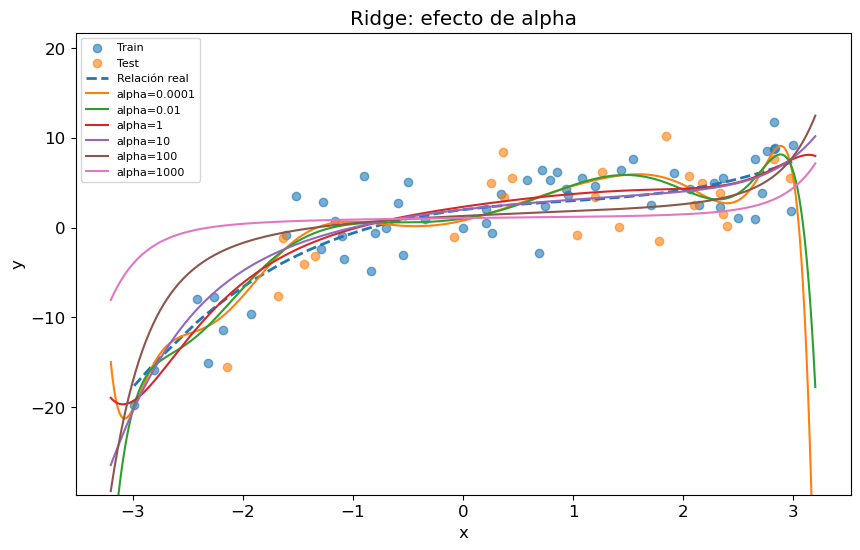

,alpha,RMSE train,RMSE test,R2 test,norma L2 coeficientes
0,0.0001,2.648846,3.567365,0.581682,202.478784
1,0.0100,2.700355,3.643583,0.563616,34.830811
2,1.0000,2.936205,3.505199,0.596135,4.856374
3,10.0000,3.059095,3.722870,0.544418,3.509848
4,100.0000,3.851472,4.447082,0.349928,1.816841
5,1000.0000,5.493578,5.161307,0.124349,0.503837


In [28]:
ridge_alphas_to_compare = [1e-4, 1e-2, 1, 10, 100, 1000]

ridge_models = {}
ridge_alpha_results = []

plt.figure(figsize=(10, 6))
plt.scatter(X_train_p[:, 0], y_train_p, alpha=0.6, label="Train")
plt.scatter(X_test_p[:, 0], y_test_p, alpha=0.6, label="Test")
plt.plot(x_poly, y_poly_true, linestyle="--", linewidth=2, label="Relación real")

for alpha in ridge_alphas_to_compare:
    ridge_model = make_pipeline(
        PolynomialFeatures(degree=degree_high, include_bias=False),
        StandardScaler(),
        Ridge(alpha=alpha)
    )
    ridge_model.fit(X_train_p, y_train_p)
    ridge_models[alpha] = ridge_model

    pred_train = ridge_model.predict(X_train_p)
    pred_test = ridge_model.predict(X_test_p)
    norm_coef = np.linalg.norm(ridge_model[-1].coef_)

    ridge_alpha_results.append({
        "alpha": alpha,
        "RMSE train": np.sqrt(mean_squared_error(y_train_p, pred_train)),
        "RMSE test": np.sqrt(mean_squared_error(y_test_p, pred_test)),
        "R2 test": r2_score(y_test_p, pred_test),
        "norma L2 coeficientes": norm_coef
    })

    plt.plot(x_plot[:, 0], ridge_model.predict(x_plot), label=f"alpha={alpha:g}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Ridge: efecto de alpha")
plt.legend(fontsize=8)
plt.ylim(y_poly.min() - 10, y_poly.max() + 10)
plt.grid(False)
plt.show()

ridge_alpha_results = pd.DataFrame(ridge_alpha_results)
ridge_alpha_results

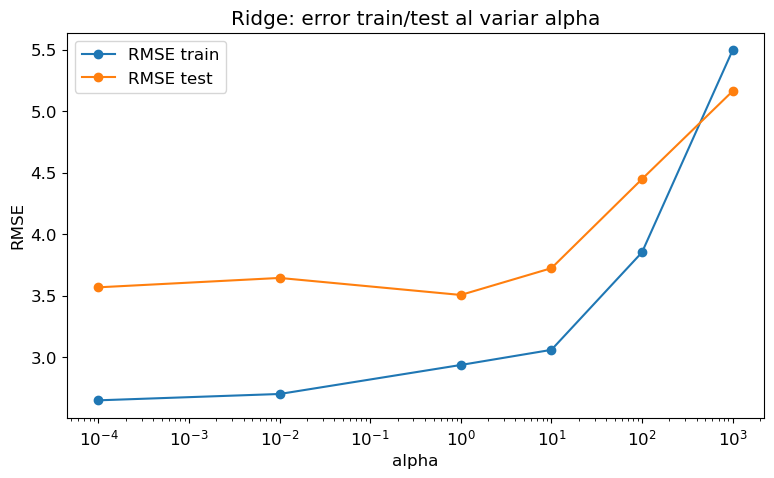

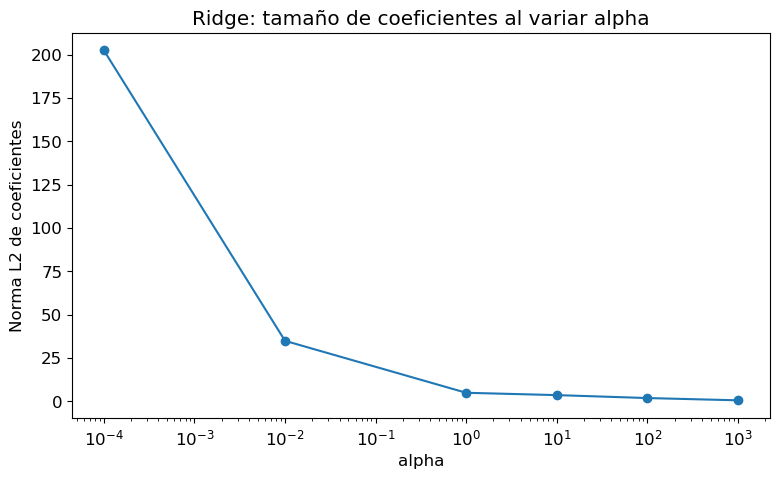

In [30]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(ridge_alpha_results["alpha"], ridge_alpha_results["RMSE train"], marker="o", label="RMSE train")
ax1.plot(ridge_alpha_results["alpha"], ridge_alpha_results["RMSE test"], marker="o", label="RMSE test")
ax1.set_xscale("log")
ax1.set_xlabel("alpha")
ax1.set_ylabel("RMSE")
ax1.grid(False)
ax1.legend(loc="upper left")

plt.title("Ridge: error train/test al variar alpha")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(ridge_alpha_results["alpha"], ridge_alpha_results["norma L2 coeficientes"], marker="o")
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Norma L2 de coeficientes")
plt.title("Ridge: tamaño de coeficientes al variar alpha")
plt.grid(False)
plt.show()

**Preguntas**
- ¿Qué ocurre con la norma de los coeficientes cuando aumenta $\alpha$?
- ¿Qué ocurre con el error de train?
- ¿Qué ocurre con el error de test?
- ¿Qué problema aparece si $\alpha$ es demasiado pequeño?
- ¿Qué problema aparece si $\alpha$ es demasiado grande?
- Conecta esto con la idea: *regularizar aumenta un poco el bias, pero puede reducir la varianza*.

1. disminuye
2. aumenta
3. aumenta
4. el modelo tiende a sobreajustar
5. el modelo es demasiado simple
6. al aumentar el valor de $\alpha$ el modelo tiende a sobreajustar lo que aumenta el bias pero disminuye la varianza

#### Conclusión
1. Completa esta tabla con tus propias palabras.

| Método | Penalización | Efecto típico en coeficientes | ¿Puede seleccionar variables? | ¿Cuándo puede ser útil? |
|---|---|---|---|---|
| Ridge | L2 | los reduce pero no a 0 | no | cuando el modelo tiene problemas leves de sobreajuste |
| Lasso | L1 | los reduce a 0 | si | cuando el modelo tiene problemas graves de sobreajuste |
| Elastic Net | L1 + L2 | reduce algunos a 0 | si | cuando el modelo tiene problemas moderados de sobreajuste |

 ¿Por qué la regularización no debe entenderse como “hacer el modelo peor”, sino como una forma de mejorar la generalización?

2. Finalmente, resumiendo todo el tema de regresión, responde
> ¿Qué significa construir un buen modelo de regresión?

No hables solo de métricas. Incluye también:

- diagnóstico del modelo
- comparación entre train y test
- residuos
- generalización
- regularización cuando corresponde

1. porque al dsminuir su complejidad evita que el modelo sobreajuste permitiendo asi una mejor generalizacion 
2. significa construir un modelo que obtenga las mejores metricas posibles que sean relevantes para el problema pero que tambien no pierda generalidad para esto se busca que las metricas de train y test sean lo más parecidas y altas posibles esto se puede lograr tanto ajustando hiperparametros del modelo como implementando regularizacion para evitar el sobreajuste.